In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("Imports successful!")

Imports successful!


In [5]:
import pandas as pd
import os

print("Current folder:", os.getcwd())

# Full path to the real CSV
file_path = "student_people_mass_uprising_public_sentiments_dataset/student_people_mass_uprising_public_sentiments_dataset.csv"

df = pd.read_csv(file_path, encoding='utf-8')

print("✅ Dataset loaded successfully!")
print("Shape (rows, columns):", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

# Quick info about the data
print("\nSentiment column value counts:")
print(df['sentiment'].value_counts() if 'sentiment' in df.columns else "No 'sentiment' column found")

Current folder: /Users/home/Desktop/premier/python projects/bangla-sentiment-analysis
✅ Dataset loaded successfully!
Shape (rows, columns): (4200, 4)

Column names: ['comment', 'language', 'platform', 'label']

First 5 rows:


,comment,language,platform,label
0,কোন সংলাপ হবে না। পদত্যাগ চাই এবং কঠোর শাস্ত...,Bangla,Facebook,Positive
1,"সব কয়টা রাজনৈতিক করে,এরা কেউ সাধারন শিক্ষার্থী নয়",Bangla,Youtube,Negative
2,অপরাধের কোন ধর্ম দলীয় পরিচয় নেই। অপরাধী রাষ্...,Bangla,Facebook,Neutral
3,ইউনুস সরকার হিন্দুদের অত্যাচার করছে।,Bangla,Facebook,Negative
4,ছাত্ররা দেশের ভবিষ্যৎ নির্মাণের মূল কারিগর।,Bangla,Twitter (X),Positive



Sentiment column value counts:
No 'sentiment' column found


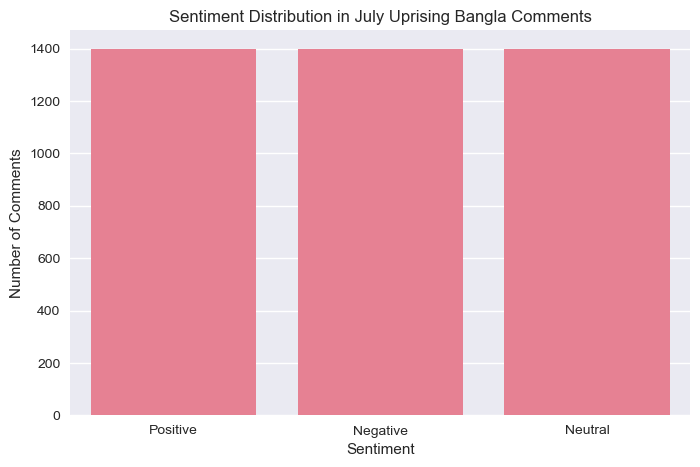

Label counts:
label
Positive    1400
Negative    1400
Neutral     1400
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sentiment distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, order=['Positive', 'Negative', 'Neutral'])
plt.title('Sentiment Distribution in July Uprising Bangla Comments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.show()

print("Label counts:")
print(df['label'].value_counts())

Comment length statistics:
count    4200.000000
mean       68.846905
std        36.168510
min         8.000000
25%        48.000000
50%        62.000000
75%        82.000000
max       349.000000
Name: text_length, dtype: float64


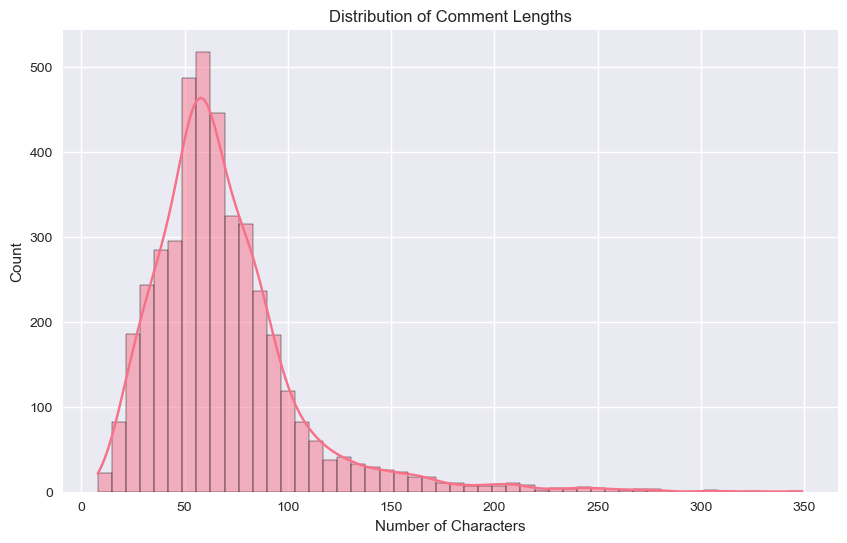

In [7]:
# Add text length column
df['text_length'] = df['comment'].astype(str).apply(len)

print("Comment length statistics:")
print(df['text_length'].describe())

# Plot length distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Distribution of Comment Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Count')
plt.show()

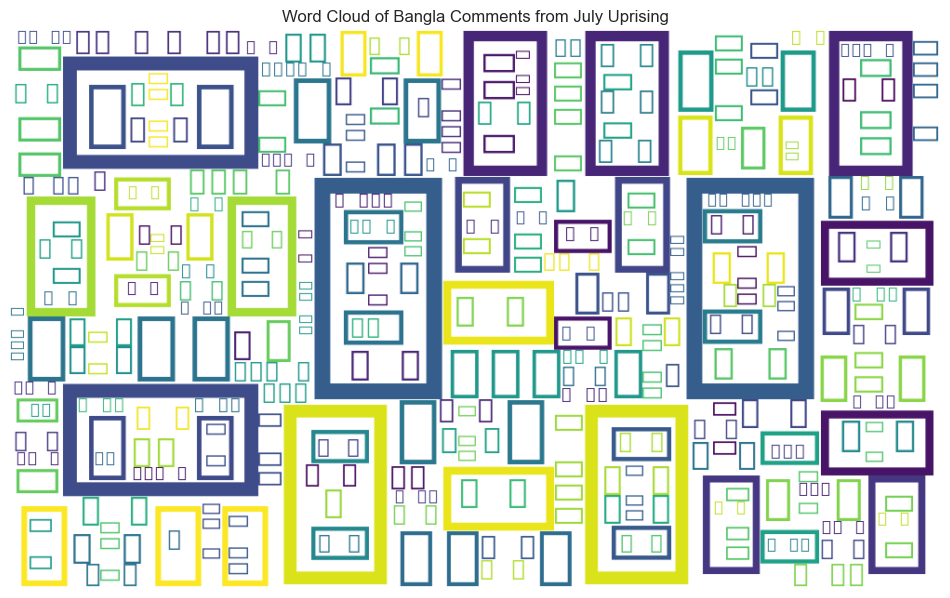

In [8]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

# Combine all comments
all_text = ' '.join(df['comment'].astype(str))

# Basic stopwords (English for now)
stop_words = set(stopwords.words('english'))

# Generate word cloud
wordcloud = WordCloud(width=1000, 
                      height=600, 
                      background_color='white',
                      stopwords=stop_words,
                      max_words=200,
                      min_font_size=10).generate(all_text)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Bangla Comments from July Uprising')
plt.show()

In [9]:
import re
import string

def clean_bangla_text(text):
    if not isinstance(text, str):
        return ""
    
    # Convert to string just in case
    text = str(text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove mentions (@username) and hashtags if too noisy
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    
    # Remove English characters and numbers (optional - keep if you want mixed)
    # text = re.sub(r'[a-zA-Z0-9]', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning
df['clean_comment'] = df['comment'].apply(clean_bangla_text)

print("✅ Text cleaning done!")
print("Sample before cleaning:")
print(df['comment'].iloc[0])
print("\nSample after cleaning:")
print(df['clean_comment'].iloc[0])

✅ Text cleaning done!
Sample before cleaning:
কোন সংলাপ হবে না। পদত্যাগ চাই এবং কঠোর শাস্তি চাই

Sample after cleaning:
কোন সংলাপ হবে না। পদত্যাগ চাই এবং কঠোর শাস্তি চাই


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Features and target
X = df['clean_comment']
y = df['label']

# Split into train and test (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train set size:", len(X_train))
print("Test set size:", len(X_test))

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000, 
                        ngram_range=(1, 2),
                        min_df=2)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("✅ TF-IDF vectorization done!")
print("Vocabulary size:", len(tfidf.get_feature_names_out()))

Train set size: 3360
Test set size: 840
✅ TF-IDF vectorization done!
Vocabulary size: 3675


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

# Predict on test set
y_pred = model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

✅ Model Accuracy: 0.8024 (80.24%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.73      0.76       280
     Neutral       0.90      0.87      0.89       280
    Positive       0.72      0.81      0.76       280

    accuracy                           0.80       840
   macro avg       0.81      0.80      0.80       840
weighted avg       0.81      0.80      0.80       840



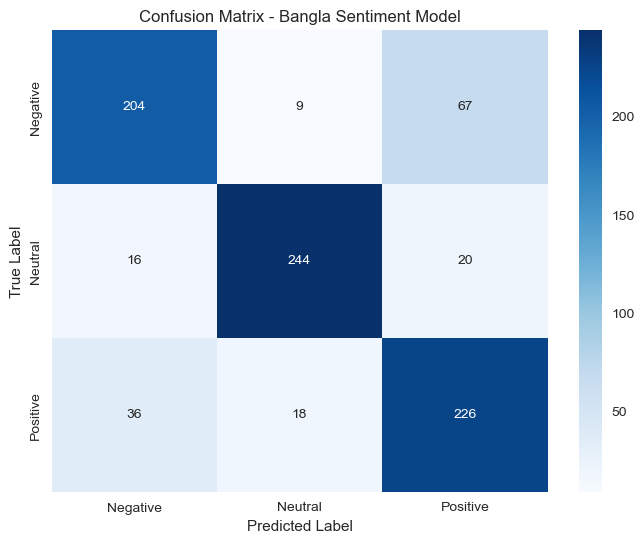

In [12]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix - Bangla Sentiment Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [13]:
import joblib
import os

# Create a models folder
os.makedirs("models", exist_ok=True)

# Save model and vectorizer
joblib.dump(model, "models/bangla_sentiment_model.pkl")
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

print("✅ Model and vectorizer saved in 'models/' folder!")

✅ Model and vectorizer saved in 'models/' folder!


In [14]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/bangla_sentiment_model.pkl")
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

print("✅ Model and vectorizer saved successfully!")

✅ Model and vectorizer saved successfully!


In [19]:
import gradio as gr
import joblib

# Load the saved model and vectorizer
model = joblib.load("models/bangla_sentiment_model.pkl")
tfidf = joblib.load("models/tfidf_vectorizer.pkl")

def predict_sentiment(text):
    cleaned = clean_bangla_text(text)
    vector = tfidf.transform([cleaned])
    prediction = model.predict(vector)[0]
    probabilities = model.predict_proba(vector)[0]
    confidence = max(probabilities) * 100
    
    return f"**{prediction}**\n\nConfidence: {confidence:.1f}%"

# Create Gradio Interface
demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=5, 
        placeholder="এখানে বাংলা কমেন্ট লিখুন..."
    ),
    outputs=gr.Markdown(),
    title="🇧🇩 Bangla Sentiment Analyzer",
    description="Trained on July 2024 Student-People Mass Uprising comments\nAccuracy: 80.24%",
    examples=[
        ["কোন সংলাপ হবে না। পদত্যাগ চাই"],
        ["ছাত্ররা দেশের ভবিষ্যৎ নির্মাণের মূল কারিগর।"],
        ["ইউনুস সরকার হিন্দুদের অত্যাচার করছে।"]
    ]
)

# Launch the demo
demo.launch(
    share=False,
    theme=gr.themes.Soft()
)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


In [20]:
!pip freeze > requirements.txt